# Sim 1 — Coverage Failure of Naive Intervals under Heteroskedasticity

**From the wiki page §7.1.** Build a heteroskedastic AR(1)+GARCH(1,1) synthetic series, fit a gradient-boosted base model, and compare three prediction-interval strategies:

1. **Parametric** — `μ̂ ± 1.645 σ` using training-residual stdev.
2. **Split CP** — finite-sample-corrected quantile of |residuals| on a held-out calibration set.
3. **EnbPI** — bootstrap-ensemble LOO residual quantile (Xu & Xie 2023).

The point of this notebook is to **see** the parametric interval fail while CP holds, and to feel where each method gives or takes width.

In [1]:
import sys
sys.path.insert(0, '/media/ak/10E1026C4FA6006E/GitRepos/ConformalIntro/notebooks')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from utils import (
    garch_ar, setup_style, save_fig,
    split_cp_quantile, enbpi_predict,
    coverage, width, rolling_coverage,
)
setup_style()
ALPHA = 0.10  # 90% target coverage
RNG_SEED = 0

## 1. Generate the synthetic series

`y_t` is an AR(1) with GARCH(1,1) innovations — the canonical heteroskedastic returns process. Five engineered features mimic lagged returns, prior shock, prior vol, and a slow seasonal.

In [2]:
series = garch_ar(T=20_000, phi=0.3, omega=1e-3, alpha=0.1, beta=0.85, seed=0)
X, y, sig2 = series.X, series.y, series.sig2
train, cal, test = slice(0, 10_000), slice(10_000, 15_000), slice(15_000, 20_000)
print(f'train={X[train].shape[0]} cal={X[cal].shape[0]} test={X[test].shape[0]}')
print(f'overall std(y)={y.std():.4f}, vol range √sig2 [{np.sqrt(sig2).min():.4f}, {np.sqrt(sig2).max():.4f}]')

train=10000 cal=5000 test=5000
overall std(y)=0.1451, vol range √sig2 [0.0885, 0.3379]


### Visualising the heteroskedasticity

Both the realised series and the latent volatility process. The vol clustering is the entire reason fixed-width intervals fail.

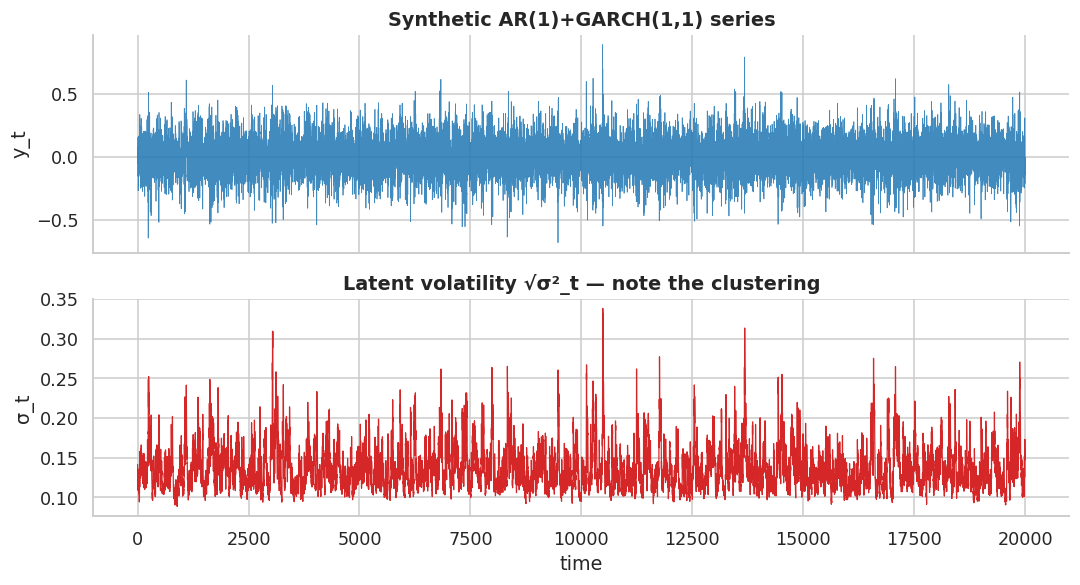

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
axes[0].plot(y, color='#1f77b4', lw=0.5, alpha=0.85)
axes[0].set_title('Synthetic AR(1)+GARCH(1,1) series')
axes[0].set_ylabel('y_t')
axes[1].plot(np.sqrt(sig2), color='#d62728', lw=0.8)
axes[1].set_title('Latent volatility √σ²_t — note the clustering')
axes[1].set_ylabel('σ_t')
axes[1].set_xlabel('time')
fig.tight_layout()
save_fig(fig, 'sim1_series_and_vol.png')
plt.show()

## 2. Fit the base model

A gradient-boosted regressor. The CP guarantee does **not** depend on this choice — we could swap in any black box and the coverage claim would still hold (under exchangeability, which we will deliberately violate in Sim 2).

In [4]:
base = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=RNG_SEED)
base.fit(X[train], y[train])
mu_train = base.predict(X[train])
mu_cal = base.predict(X[cal])
mu_test = base.predict(X[test])
print(f'train R² = {1 - ((y[train]-mu_train)**2).sum()/((y[train]-y[train].mean())**2).sum():.4f}')

train R² = 0.2614


## 3. Build the three interval methods

### A. Parametric ±1.645σ
Treats the residuals as iid Gaussian — the assumption every quant who has fit a linear model already knows is wrong, but still reaches for.

In [5]:
sigma_train = (y[train] - mu_train).std()
A_lo = mu_test - 1.645 * sigma_train
A_hi = mu_test + 1.645 * sigma_train
print(f'parametric half-width = 1.645 * {sigma_train:.4f} = {1.645*sigma_train:.4f}')

parametric half-width = 1.645 * 0.1248 = 0.2054


### B. Split conformal prediction

The simplest CP recipe: empirical (1−α) quantile of |y − μ̂| on the calibration set, finite-sample-corrected by `⌈(n+1)(1−α)⌉/n`.

In [6]:
cal_residuals = y[cal] - mu_cal
q_hat = split_cp_quantile(cal_residuals, alpha=ALPHA)
B_lo = mu_test - q_hat
B_hi = mu_test + q_hat
print(f'split-CP half-width = {q_hat:.4f}')

split-CP half-width = 0.2305


### C. EnbPI (bootstrap-ensemble LOO)

20 bootstrap GBMs; LOO predictions on the training set provide the residual pool. Avoids splitting away calibration data — more efficient when data is precious. (Validity here is asymptotic and requires β-mixing, not exchangeability.)

In [7]:
from sklearn.ensemble import GradientBoostingRegressor
mu_enb, C_lo, C_hi = enbpi_predict(
    GradientBoostingRegressor,
    dict(n_estimators=120, max_depth=4, random_state=RNG_SEED),
    X[train], y[train], X[test],
    B=20, alpha=ALPHA, seed=RNG_SEED,
)
print(f'EnbPI mean half-width = {(C_hi - C_lo).mean()/2:.4f}')

EnbPI mean half-width = 0.2296


## 4. Compare coverage and width

In [8]:
rows = []
for name, lo, hi in [
    ('Parametric ±1.645σ', A_lo, A_hi),
    ('Split CP', B_lo, B_hi),
    ('EnbPI', C_lo, C_hi),
]:
    rows.append({
        'method': name,
        'coverage': coverage(y[test], lo, hi),
        'mean width': width(lo, hi),
    })
summary = pd.DataFrame(rows).set_index('method')
summary

,coverage,mean width
method,,
Parametric ±1.645σ,0.8722,0.410711
Split CP,0.9086,0.461034
EnbPI,0.9098,0.459272


### Coverage and width — at a glance

If the wiki claim holds, parametric should land short of 0.90 while split CP and EnbPI sit on it. Width tells you what the coverage cost.

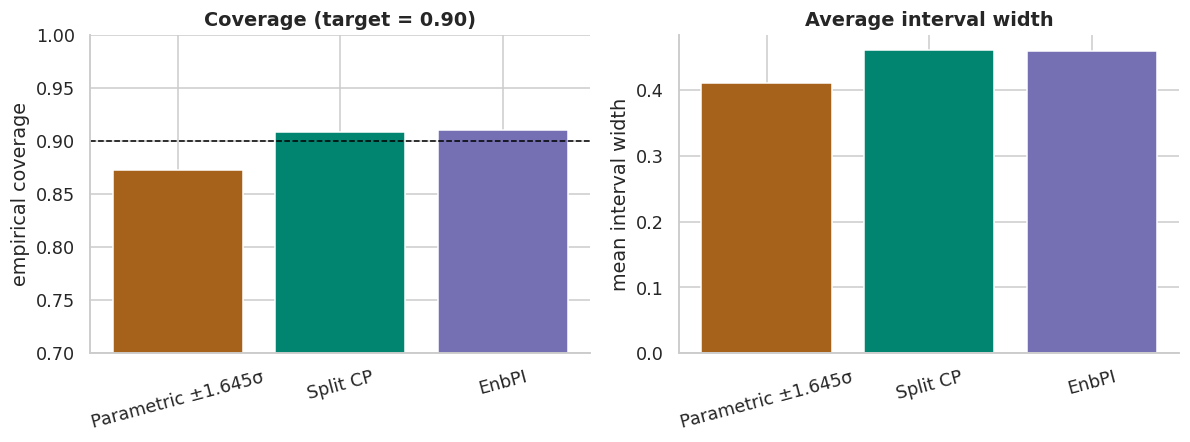

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
colors = ['#a6611a', '#018571', '#7570b3']
axes[0].bar(summary.index, summary['coverage'], color=colors)
axes[0].axhline(1 - ALPHA, color='black', ls='--', lw=1)
axes[0].set_ylim(0.7, 1.0)
axes[0].set_ylabel('empirical coverage')
axes[0].set_title('Coverage (target = 0.90)')
for tick in axes[0].get_xticklabels(): tick.set_rotation(15)
axes[1].bar(summary.index, summary['mean width'], color=colors)
axes[1].set_ylabel('mean interval width')
axes[1].set_title('Average interval width')
for tick in axes[1].get_xticklabels(): tick.set_rotation(15)
fig.tight_layout()
save_fig(fig, 'sim1_coverage_width.png')
plt.show()

## 5. Where the parametric interval fails

Stratify the test set by latent vol decile. Parametric coverage should collapse in the high-vol bins; CP and EnbPI should stay flat — that's the practical meaning of *conditional* coverage.

In [10]:
test_vol = np.sqrt(sig2[test])
deciles = pd.qcut(test_vol, 10, labels=False)
bins = pd.DataFrame({'decile': deciles})
for name, lo, hi in [('Parametric', A_lo, A_hi), ('Split CP', B_lo, B_hi), ('EnbPI', C_lo, C_hi)]:
    bins[name] = ((y[test] >= lo) & (y[test] <= hi)).astype(float)
by_decile = bins.groupby('decile').mean()
by_decile

,Parametric,Split CP,EnbPI
decile,,,
0,0.936,0.966,0.970
1,0.936,0.960,0.958
2,0.930,0.952,0.954
3,0.912,0.942,0.942
4,0.912,0.958,0.956
5,0.874,0.908,0.906
6,0.868,0.908,0.914
7,0.842,0.876,0.878
8,0.792,0.844,0.844


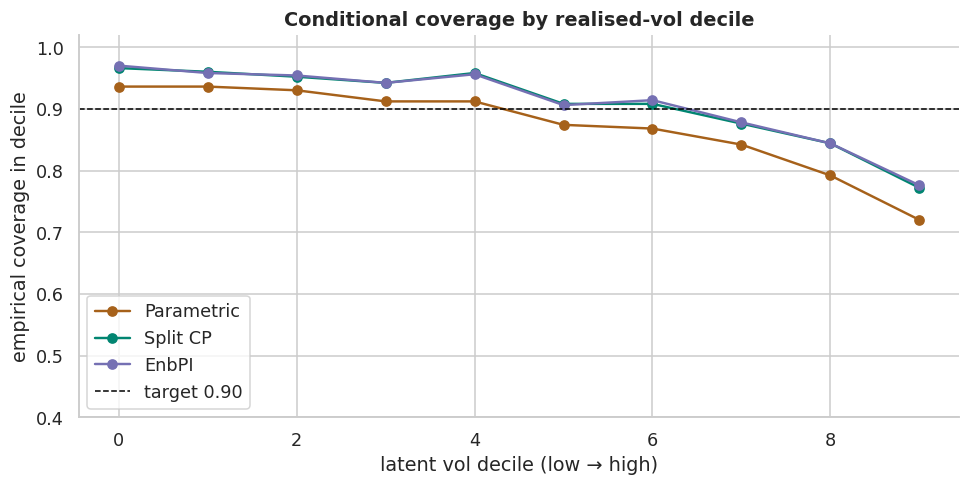

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.6))
for name, color in zip(['Parametric', 'Split CP', 'EnbPI'], colors):
    ax.plot(by_decile.index, by_decile[name], 'o-', label=name, color=color)
ax.axhline(1 - ALPHA, color='black', ls='--', lw=1, label='target 0.90')
ax.set_xlabel('latent vol decile (low → high)')
ax.set_ylabel('empirical coverage in decile')
ax.set_title('Conditional coverage by realised-vol decile')
ax.set_ylim(0.4, 1.02)
ax.legend()
fig.tight_layout()
save_fig(fig, 'sim1_conditional_coverage.png')
plt.show()

## 6. Visualising intervals over a high-vol window

Zoom into a turbulent 500-step segment and overlay the three intervals. Parametric is a constant tube; CP/EnbPI may still be flat-ish here because their score isn't `σ̂`-scaled yet — but they trade *coverage* for narrower mean width in calm regimes.

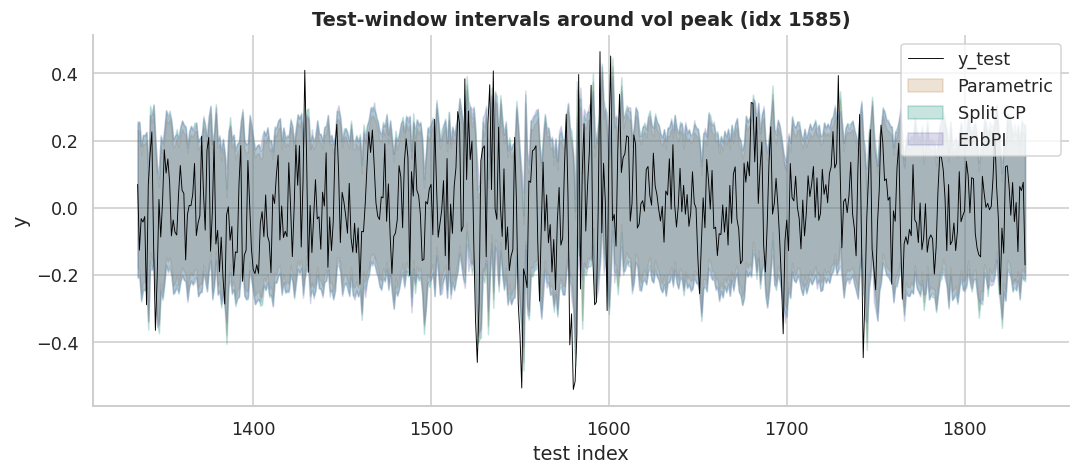

In [12]:
vol_test = np.sqrt(sig2[test])
peak = int(np.argmax(vol_test))
lo_zoom = max(0, peak - 250); hi_zoom = min(len(vol_test), peak + 250)
z = slice(lo_zoom, hi_zoom)
t_axis = np.arange(lo_zoom, hi_zoom)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(t_axis, y[test][z], color='black', lw=0.6, label='y_test')
ax.fill_between(t_axis, A_lo[z], A_hi[z], color='#a6611a', alpha=0.18, label='Parametric')
ax.fill_between(t_axis, B_lo[z], B_hi[z], color='#018571', alpha=0.22, label='Split CP')
ax.fill_between(t_axis, C_lo[z], C_hi[z], color='#7570b3', alpha=0.25, label='EnbPI')
ax.set_title(f'Test-window intervals around vol peak (idx {peak})')
ax.set_xlabel('test index'); ax.set_ylabel('y')
ax.legend(loc='upper right')
fig.tight_layout()
save_fig(fig, 'sim1_intervals_zoom.png')
plt.show()

## 7. Takeaway

- Parametric undercovers globally and collapses in high-vol bins.
- Split CP holds marginally because the residuals were exchangeable enough   across this stationary GARCH window.
- EnbPI matches Split CP on coverage without burning a calibration set.
- **Width-adaptive scoring (σ̂-scaling, CQR) is the next lever** — Sim 3 picks that up.
- **Coverage holds, but conditional coverage by vol bin is still uneven** for non-adaptive   scores. That's why §5 of the wiki insists on `σ̂`-scaling or CQR scores for HFT use.